# Imitation Teacher
We saw that (unsurprisingly) a student model can learn from a teacher model when the feature spaces are the same and the teacher has full access to the student's weight vector $w$. However, this isn't how things work in a more practical setting. It's unlikely that the teacher will know what the student is 'thinking' and it's also unlikelythat they both 'understand' the problem in the same way (have the same feature space).

The imitation teacher imitates the inner product of the student $\langle w^t, x \rangle$ and chooses example from the teacher's own feature space.

Let's implement it and see if we can work it out.

### Set up
Firstly we need some data and a teacher. So let's generate some data and learn a model that will be our teacher. We won't worry about the diference in feature space for now.

In [129]:
import numpy as np
import pylab as pl
import random

ETA = 0.01
NUM_DATA_POINTS = 40

In [130]:
# Generates 2D data that is linearly separable - no overlap
def gen_lin_separable_data(n):
    # generate training data in the 2-d case
    mean1 = np.array([0, 0])
    mean2 = np.array([4, 4])
    cov = np.array([[0.8, -0.6], [-0.6, 0.8]])
    X1 = np.random.multivariate_normal(mean1, cov, (n//2))
    y1 = np.ones(len(X1))
    X2 = np.random.multivariate_normal(mean2, cov, (n//2))
    y2 = np.ones(len(X2)) * -1
    return X1, y1, X2, y2

In [131]:
def plot_margin(X1_train, X2_train, clf):
    def f(x, w, b, c=0):
        # given x, return y such that [x,y] in on the line
        # w.x + b = c
        return (-w[0][0] * x - b + c) / w[0][1]

    pl.plot(X1_train[:,0], X1_train[:,1], "ro", label="Class +1")
    pl.plot(X2_train[:,0], X2_train[:,1], "bo", label="Class -1")
    pl.scatter(clf.support_vectors_[:,1], clf.support_vectors_[:,2], s=100, c="g")

    # w.x + b = 0
    a0 = -5; a1 = f(a0, clf.coef_[:,1:], clf.intercept_)
    b0 = 5; b1 = f(b0, clf.coef_[:,1:], clf.intercept_)
    pl.plot([a0,b0], [a1,b1], "k")

    # w.x + b = 1
    a0 = -5; a1 = f(a0, clf.coef_[:,1:], clf.intercept_, 1)
    b0 = 5; b1 = f(b0, clf.coef_[:,1:], clf.intercept_, 1)
    pl.plot([a0,b0], [a1,b1], "k--")

    # w.x + b = -1
    a0 = -5; a1 = f(a0, clf.coef_[:,1:], clf.intercept_, -1)
    b0 = 5; b1 = f(b0, clf.coef_[:,1:], clf.intercept_, -1)
    pl.plot([a0,b0], [a1,b1], "k--")

    pl.xlabel('x1')
    pl.ylabel('x2')

    #pl.legend(numpoints=1)

    #pl.axis("tight")
    pl.show()

In [132]:
def plot_margin_bare(X1_train, X2_train, weights, bias):
    def f(x, w, b, c=0):
        # given x, return y such that [x,y] in on the line
        # w.x + b = c
        return (-w[0][0] * x - b + c) / w[0][1]

    pl.plot(X1_train[:,0], X1_train[:,1], "ro", label="Class +1")
    pl.plot(X2_train[:,0], X2_train[:,1], "bo", label="Class -1")

    # w.x + b = 0
    a0 = -5; a1 = f(a0, weights, bias)
    b0 = 5; b1 = f(b0, weights, bias)
    pl.plot([a0,b0], [a1,b1], "k")

    # w.x + b = 1
    a0 = -5; a1 = f(a0, weights, bias, 1)
    b0 = 5; b1 = f(b0, weights, bias, 1)
    pl.plot([a0,b0], [a1,b1], "k--")

    # w.x + b = -1
    a0 = -5; a1 = f(a0, weights, bias, -1)
    b0 = 5; b1 = f(b0, weights, bias, -1)
    pl.plot([a0,b0], [a1,b1], "k--")

    pl.xlabel('x1')
    pl.ylabel('x2')

    #pl.legend(numpoints=1)

    #pl.axis("tight")
    pl.show()

In [133]:
x1, y1, x2, y2 = gen_lin_separable_data(NUM_DATA_POINTS)
l_sep = np.vstack((x1,x2))
lin_sep = np.ones((len(l_sep),len(l_sep[0])+1))
lin_sep[:,1:] = l_sep
Y = np.hstack((y1,y2))

In [157]:
from sklearn import svm
clf = svm.SVC()
clf.set_params(kernel='linear')
clf.fit(lin_sep, Y)
clf.intercept_

array([ 1.34560473])

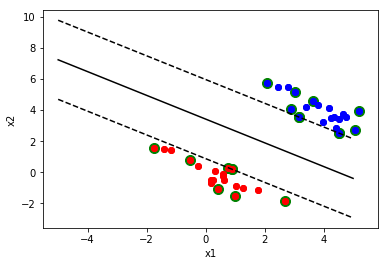

In [158]:
plot_margin(l_sep[Y==1], l_sep[Y==-1], clf)

### Step 1
Randomly initialize the student parameter $w^0$ and the techer parameer $v^0$; Randomly select a training sample $(x^0, y^0)$;

In [159]:
studentW = np.array([random.random(), random.random(), random.random()])
v = np.array([random.random(), random.random(), random.random()])
teacherV = np.append(clf.intercept_, clf.coef_[:,1:])
studentW, teacherV, v, clf.intercept_

(array([ 0.71941729,  0.09531317,  0.38177803]),
 array([ 1.34560473, -0.29975593, -0.39334128]),
 array([ 0.74217504,  0.5674972 ,  0.25304742]),
 array([ 1.34560473]))

In [137]:
index = random.randint(0,NUM_DATA_POINTS)
x_n = lin_sep[index]
y_n = Y[index]
x_n, y_n

(array([ 1.        ,  4.19940196,  4.12108977]), -1.0)

### Step 2
set $t=1$ and the maximal iteration nuber $T$;

In [138]:
t=1
T=5

### Step 3: The last one
**while** $w^t$ has not converged or $t<T$ **do**
    1. Perform the update 
$$v^t = v^{t-1} - \eta_v (\langle v^{t-1}, x^{t-1} \rangle - \langle w^t , x^{t-1} \rangle)x^{t-1}$$
    2. Solve the optimization (e.g. pool-based teaching):
$$ (x^t , y^t) = \min_{x\in X , y\in Y} \eta^2_t \| \frac{\partial \ell (\langle w^t, x \rangle), y)}{\partial v^t} \|^2 - 2\eta _t \langle v^t - v^* , \frac{\partial \ell (\langle v^t , x \rangle , y)}{\partial v^t} \rangle $$
    3. Provide the selected example (x^t , y^t) for the student to perform the update
$$ w^{t+1} = w^t - \eta _t \frac{\partial \ell (\langle w^t , x \rangle , y)}{\partial w} $$
    4. t = t+1
**end while**

In [139]:
def update_teacher(v, w, learning_rate, x):
    return v - learning_rate * (np.dot(v, x) - np.dot(w, x)) * x

In [140]:
def sq_loss(w, x, y):
    return 0.5*(np.dot(w, x) - y)**2

In [141]:
def der_sq_loss(w, x, y):
    return x * ((np.dot(w,x))-y)

In [142]:
def get_arg_min(learning_rate, w, v, X, Y, vS):
    minVal = (2**31)-1
    minInd = (2**31)-1
    for i in range(0, len(X)):
        p1 = learning_rate**2 * np.linalg.norm(der_sq_loss(w, X[i], Y[i]))**2
        p2 = 2*learning_rate*np.dot(v-vS, der_sq_loss(v, X[i], Y[i]))
        if (p1 - p2) < minVal:
            minVal = p1 - p2
            minInd = i
    return (X[minInd], Y[minInd])

In [143]:
print(get_arg_min(ETA, studentW, v, lin_sep, Y, teacherV))

(array([ 1.        ,  5.20624671,  3.93060395]), -1.0)


In [144]:
def update_weight(w, learn_rate, x, y):
    return w - learn_rate * der_sq_loss(w, x, y)

In [145]:
while (not np.array_equal(studentW, teacherV) and t < T): 
    v = update_teacher(v, studentW, ETA, x_n)
    x_n, y_n = get_arg_min(ETA, studentW, v, lin_sep, Y, teacherV)
    studentW = update_weight(studentW, ETA, x_n, y_n)
    t +=1

In [146]:
studentW, teacherV, v, clf.intercept_

(array([ 0.50457689, -0.22429475,  0.17045961]),
 array([ 1.34560473, -0.29975593, -0.39334128]),
 array([-0.07968649,  0.30359215,  0.37443448]),
 array([ 1.34560473]))

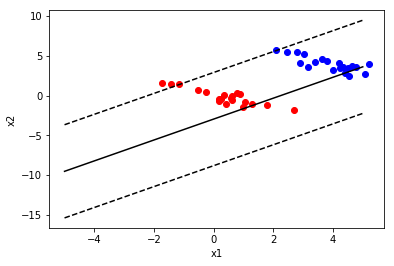

In [147]:
plot_margin_bare(l_sep[Y==1], l_sep[Y==-1], [studentW[1:]], studentW[0])

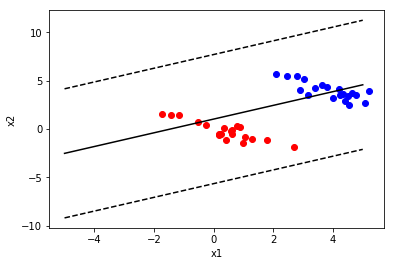

In [148]:
studentW = np.array([random.random(), random.random(), random.random()])
v = np.array([random.random(), random.random(), random.random()])
index = random.randint(0,NUM_DATA_POINTS)
x_n = lin_sep[index]
y_n = Y[index]
t = 1
T = 5
while (not np.array_equal(studentW, teacherV) and t < T): 
    v = update_teacher(v, studentW, ETA, x_n)
    x_n, y_n = get_arg_min(ETA, studentW, v, lin_sep, Y, teacherV)
    studentW = update_weight(studentW, ETA, x_n, y_n)
    t +=1
plot_margin_bare(l_sep[Y==1], l_sep[Y==-1], [studentW[1:]], studentW[0])

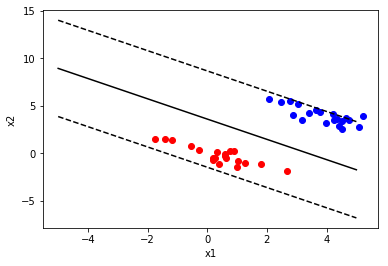

In [149]:
studentW = np.array([random.random(), random.random(), random.random()])
v = np.array([random.random(), random.random(), random.random()])
index = random.randint(0,NUM_DATA_POINTS)
x_n = lin_sep[index]
y_n = Y[index]
t = 1
T = 50
while (not np.array_equal(studentW, teacherV) and t < T): 
    v = update_teacher(v, studentW, ETA, x_n)
    x_n, y_n = get_arg_min(ETA, studentW, v, lin_sep, Y, teacherV)
    studentW = update_weight(studentW, ETA, x_n, y_n)
    t +=1
plot_margin_bare(l_sep[Y==1], l_sep[Y==-1], [studentW[1:]], studentW[0])

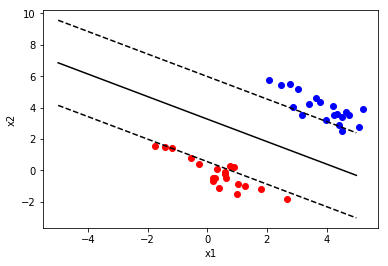

In [150]:
studentW = np.array([random.random(), random.random(), random.random()])
v = np.array([random.random(), random.random(), random.random()])
index = random.randint(0,NUM_DATA_POINTS)
x_n = lin_sep[index]
y_n = Y[index]
t = 1
T = 500
while (not np.array_equal(studentW, teacherV) and t < T): 
    v = update_teacher(v, studentW, ETA, x_n)
    x_n, y_n = get_arg_min(ETA, studentW, v, lin_sep, Y, teacherV)
    studentW = update_weight(studentW, ETA, x_n, y_n)
    t +=1
plot_margin_bare(l_sep[Y==1], l_sep[Y==-1], [studentW[1:]], studentW[0])

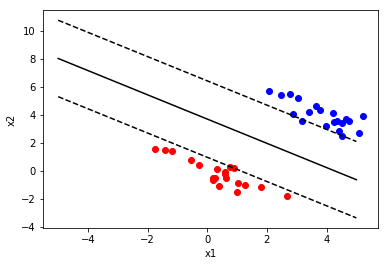

In [151]:
studentW = np.array([random.random(), random.random(), random.random()])
v = np.array([random.random(), random.random(), random.random()])
index = random.randint(0,NUM_DATA_POINTS)
x_n = lin_sep[index]
y_n = Y[index]
t = 1
T = 5000
while (not np.array_equal(studentW, teacherV) and t < T): 
    v = update_teacher(v, studentW, ETA, x_n)
    x_n, y_n = get_arg_min(ETA, studentW, v, lin_sep, Y, teacherV)
    studentW = update_weight(studentW, ETA, x_n, y_n)
    t +=1
plot_margin_bare(l_sep[Y==1], l_sep[Y==-1], [studentW[1:]], studentW[0])

## Some Questions (and hopefully answers)
- What is $v$?
    - $v$ is the teacher's internal representation of what it believes student's $w$ to be. The teacher does not have access to $w$, it only has access to the out put of $\langle w^t, x \rangle$.
- What is meant by different feature spaces?
    - $w$ may have a different feature space to $v$, we don't know. We only observe $w$ through it's behaviour interacting with the teacher's representation of $x$. This does require that we have access to $\langle w , x \rangle $ though. In the game idea, we would only have access to $f(w,x)$, so leaving us with something to think about.